# Tutorial 4: Deep Learning Basics with PyTorch


This tutorial introduces the **end-to-end workflow of training neural networks in PyTorch**:
tensors -> automatic differentiation -> model definition -> training loop -> evaluation.

You’ll start with small, concrete examples (so you can *see* what gradients are doing), then train an **Multilayer Perceptron** (MLP) on MNIST, and finally apply the same ideas to a **regression** task.

At the end, there is an **Optional Advanced** section with extra experiments (deeper gradient demonstrations and Convolutional Neural Networks (CNNs)). It’s there for curiosity and extension, note that the main tutorial does **not** depend on it.

\
**Learning goals**
- Understand tensor shapes and why they matter (most bugs are shape bugs!)
- Use **autograd** to compute gradients and reason about backpropagation
- Write a clean training loop: forward -> loss -> backward -> optimizer step -> evaluate
- Train an MLP classifier and interpret loss/accuracy
- Reuse the same training pattern for regression

\
**How to use this notebook**
- Run cells **top-to-bottom**.
- If you have a GPU in Colab: *Runtime -> Change runtime type -> GPU* (optional).
- When you see **Task** prompts, try them first, then check the provided solution.

<br>

---


<a id="toc"></a>
## Table of Contents
1. [Setup](#1-setup)
2. [Tensors and Autograd: Computing Gradients](#2-tensors-and-autograd-computing-gradients)
3. [Multilayer Perceptron (MLP) for MNIST](#3-multilayer-perceptron-mlp-for-mnist)
4. [Exercise: Regression with an MLP (California Housing)](#4-exercise-regression-with-an-mlp-california-housing)
5. [Optional Advanced: Convolutional Neural Networks (CNNs)](#5-optional-advanced-convolutional-neural-networks-cnns)

## 1. Setup
<a id="sec1"></a>

[⬆️ Back to Table of Contents](#toc)

We start by installing/importing PyTorch, choosing CPU vs GPU

- Colab setup: install PyTorch/torchvision if needed (may already be installed).
If you are using a local environment, you can skip this step if you have already installed PyTorch.
- You can also specify a particular version of PyTorch if your code requires it.
- Also, it can be a good practice to use a ***virtual environment*** for your project to manage dependencies and avoid conflicts between different projects.
  - You can create a virtual environment using tools like `venv` or `conda`, and then install the required packages within that environment. This way, you can ensure that your project has the correct versions of libraries without affecting other projects on your system.


In [1]:
!pip install torch torchvision # pip often install the latest version of torch, which may not be compatible with your code. You can specify a version if needed, e.g., !pip install torch==1.9.0 torchvision==0.10.0
                               # torchvision is a package that provides popular datasets, model architectures, and image transformations for computer vision tasks. It is often used in conjunction with PyTorch for building and training neural networks on image data


In [2]:
# import torch and print the version we are using.
import torch
print("Using torch", torch.__version__)

Using torch 2.10.0+cu128


By default, all operations are performed using [CPU](https://en.wikipedia.org/wiki/Central_processing_unit). For a much faster performance, we can instead use [GPU](https://en.wikipedia.org/wiki/Graphics_processing_unit). First, we check if CUDA is available, if so, we set the device to `cuda` (otherwise, we stick with CPU).

If you're using Colab and the below code prints "Device: CPU", you can change the runtime type to GPU (or [TPU](https://en.wikipedia.org/wiki/Tensor_Processing_Unit), if you fancy it).

If you are using Mac with M-series chips, you can use `torch.backends.mps.is_available()` to check if you can use the GPU. If it returns `True`, you can set `device = torch.device("mps")` to use the GPU (MPS short for Metal Performance Shaders). However, note that **not all** operations are supported on MPS, so you may encounter some issues when using it. You can refer to the PyTorch and Mac documentation for more details on MPS support: https://pytorch.org/docs/stable/notes/mps.html; https://developer.apple.com/metal/pytorch/

In [3]:
# Check whether a GPU is available and choose the device accordingly
# Using a GPU can significantly speed up training

gpu_avail = torch.cuda.is_available()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {device}")

Device: cuda


## 2. Tensors and Autograd: Computing Gradients
<a id="sec2"></a>

[⬆️ Back to Table of Contents](#toc)

In this part, we refresh the definitions of tensors and their ranks (scalar/vector/matrix), then explore how PyTorch tracks operations and computes gradients using **autograd**.

<br>

### 2.1 Tensors

A tensor is an algebraic object that generalizes vectors and matrices to higher dimensions. Tensors have ranks (a.k.a. number of axes):
- Rank 0: Scalar (a single number); Shape: `()`
- Rank 1: Vector (one-dimensional array); Shape: `(n,)`
- Rank 2: Matrix (two-dimensional array); Shape: `(m,n)`
- Higher-order tensors 3+, i.e., Rank $k$: Multidimensional arrays; Shape: `(d1, d2, ..., dk)`

\
Important:
- **rank** (ndim) = `len(shape)`, number of axes
- **shape** = sizes along *each* axis

\
In deep learning (DL), tensors are often used to represent data because GPUs and TPUs can process tensors efficiently.

<br>

> **Intuition: tensors are just n-dimensional arrays**  
> - The **shape** tells you how data is organised (batch, channels, height, width, …).  
> - Most DL errors come from mismatched shapes, when debugging, print shapes early and often.  
> - In PyTorch, gradients are tracked only for tensors with `requires_grad=True`.

In [4]:
# examples
a = torch.tensor(3.0)           # scalar
b = torch.tensor([1.0, 2.0])    # vector
c = torch.zeros(2, 3)           # matrix
d = torch.zeros(4, 2, 3)        # rank-3 tensor

print("a:", a.shape, "rank:", a.ndim)
print("b:", b.shape, "rank:", b.ndim)
print("c:", c.shape, "rank:", c.ndim)
print("d:", d.shape, "rank:", d.ndim)

a: torch.Size([]) rank: 0
b: torch.Size([2]) rank: 1
c: torch.Size([2, 3]) rank: 2
d: torch.Size([4, 2, 3]) rank: 3


Typical ML/DL tensor shapes
- Tabular batch: `(batch, features)`
- Sequence batch: `(batch, time, features)` or `(time, batch, features)`
- Images (PyTorch): `(batch, channels, height, width)`
- Videos: `(batch, channels, time, height, width)`

Each axis is just an indexing direction, after 3D we stop visualizing physically and think them as "multi-index arrays".


In [5]:
# Also, when new to tensor, you may easily get confused with scalar, a vector with one component, and matrix with one element, for example:

scalar = torch.tensor(3.0)      # rank 0
vector1 = torch.tensor([3.0])   # rank 1
matrix1 = torch.tensor([[3.0]]) # rank 2

print("scalar:", scalar.shape, scalar.ndim)
print("vector1:", vector1.shape, vector1.ndim)
print("matrix1:", matrix1.shape, matrix1.ndim)

scalar: torch.Size([]) 0
vector1: torch.Size([1]) 1
matrix1: torch.Size([1, 1]) 2


In the example above, even though all of them only contains one number 3.0, they represent tensors with different ranks...

In DL, a lot of bugs come from tensor shape mismatches, you might want to make sure you understand these concepts clearly before playing around with more involved examples... (I learned these lessons the hard way...)

For the example above

| Tensor | Shape   | Rank |
| ------ | ------- | ---- |
| scalar | `()`    | 0    |
| vector | `(1,)`  | 1    |
| matrix | `(1,1)` | 2    |

**Rank ≠ number of elements.** Rank = number of *indexing* directions.

In [6]:
# one more example of matrix and scalar
matrix = torch.rand(1,1)
print(matrix[0][0])   # two indices -> rank 2

scalar = torch.tensor(5.0)
print(scalar.item())  # no indices -> rank 0
                      # .item() is used to get the Python scalar value from a single-element tensor
                      # if you want to see the value as a tensor instead of a scalar value, you can simply print without calling .item()
print(scalar)
print(matrix)         # in the printed result, you can clearly tell the rank as well by checking the [] around it

# here, even through matrix is rank 2, but because it only contains a single-element, we can call .item()
print(matrix.item())

# if a tensor contains more than a single-element, calling .item() will lead to an error
matrix_2 = torch.rand(1,2)
try:
  print(matrix_2.item())
except:
  print("a Tensor with 2 elements cannot be converted to Scalar")


tensor(0.3895)
5.0
tensor(5.)
tensor([[0.3895]])
0.3895050287246704
a Tensor with 2 elements cannot be converted to Scalar


### 2.2 Autograd intuition

Autograd builds a **computation graph** as you do operations on tensors with `requires_grad=True`.

- Each operation creates a node in the graph
- Autograd stores enough information to apply the **chain rule** backward
- When you call `.backward()`, PyTorch walks the graph in reverse and accumulates gradients into `.grad`

*Key idea*: autograd is efficient because it computes gradients **without explicitly building full Jacobians** for large systems.

In [7]:
# Let's start by checking a tiny graph

# by default, requires_grad is False, which means that PyTorch will not track operations on this tensor for automatic differentiation
x1 = torch.tensor(2.0)  # creat a rank 0 tensor (scalar) with value 2.0
print("x1 Gradient tracking:", x1.requires_grad)

# If you want to enable gradient tracking for a tensor, you can set requires_grad=True when creating the tensor, e.g., x = torch.rand(2.0, requires_grad=True)
x2 = torch.tensor(2.0, requires_grad=True)
print("x2 Gradient tracking:", x2.requires_grad)

y = x2**2 + 3*x2 + 1 # x2 is used in the computation of y, so PyTorch will track the operations on x2 and compute gradients with respect to it during backpropagation
print("y =", y.item()) # .item() is used to get the Python scalar value from a single-element tensor. This is useful for printing or using the value in other computations without the overhead of a tensor
print("y =", y) # if you want to see the value of y as a tensor instead of a scalar value, you can simply print y without calling .item().
                # This will show the value of y as a tensor, which can be useful for debugging or when working with higher-dimensional tensors where the value may not be a single scalar.
                # in this case, y is a rank 0 tensor (scalar) with the computed value, and printing it directly will show the tensor representation of that scalar value
print("shape of y:", y.shape, "rank:", y.ndim)
y.backward() # This will compute the gradients of y with respect to x2 and store it in x2.grad.
print("dy/dx =", x2.grad.item()) # when we just want to scalar value
print("dy/dx =", x2.grad)  # when we want to check the data type and the value

x1 Gradient tracking: False
x2 Gradient tracking: True
y = 11.0
y = tensor(11., grad_fn=<AddBackward0>)
shape of y: torch.Size([]) rank: 0
dy/dx = 7.0
dy/dx = tensor(7.)


We had:  
$y = x_2^2 + 3x_2 + 1$, with $ \frac{dy}{dx_2} = 2x_2 + 3$

\
At $x_2=2.0$, we have $2 * 2.0 + 3 = 7.0$, which maatches what PyTorch obtained.


***Also, don't confuse Python scalar with PyTorch scalar***

Python scalar:
- No shape
- No gradient tracking
- No device (CPU/GPU/...)

PyTorch 0-d tensor:
- Shape `()`
- Can require gradients
- Can on GPU (e.g., `cuda`, `mps`, `xpu`)/CPU
- Part of computation graph

***Why True 0-D Tensors Matter***

In DL, a loss function is often involved, and loss values in neural networks must:
- Participate in autograd
- Track gradient history
- Live on the device, GPU/CPU
- Support dtype/device
- Therefore, PyTorch represents scalars as rank-0 tensors, not Python floats

Make sure to declare them with the correct data type

In [8]:
a = 3.0                # Python float
b = torch.tensor(3.0, requires_grad=True)  # PyTorch 0-d tensor, i.e., rank 0

print(type(a))
print(type(b))
print(b.shape)

c = 2 * a
d = 2 * b

d.backward()

try:
    c.backward()
except:
    print("c has no attribute 'backward'")

<class 'float'>
<class 'torch.Tensor'>
torch.Size([])
c has no attribute 'backward'


### 2.3 Gradients, Jacobians, Hessians (Optional)

*This section mainly explains how to use `.backward()`, specifically, when we need to pass argument ($v$) to it. For now, you just need to **remember that `backward()` computes gradients of the scalar output w.r.t. tensors with requires_grad=True. For a vector/matrix output, you need to reduce it to a scalar first (e.g., mean or sum) if you are not passing any argument to it.***

You can move on to Section 2.4 if not interested in all the technical details.

---

\
For people interested in knowing the details, you can read through the following materials.

\
This section connects the **math definitions** of gradients/Jacobians/Hessians with the **tensor shapes** you will see in PyTorch.

\
*Key setup and vocabulary*

Let a function be:
$
y = f(x), \quad x \in \mathbb{R}^n,\quad y \in \mathbb{R}^m
$

- **Mathematical input dimension** $n$: number of scalar input variables.
- **Mathematical output dimension** $m$: number of scalar output components.
- **Tensor shape / rank** in PyTorch: how you *represent* those variables as tensors:
  - rank = `tensor.ndim`
  - shape = `tensor.shape`

⚠️ Important: A single real variable (mathematically $n=1$) can be represented in PyTorch in more than one way:
- as a **0-d tensor** (shape `()`, rank 0), e.g. `torch.tensor(2.0)`
- as a **length-1 vector** (shape `(1,)`, rank 1), e.g. `torch.tensor([2.0])`
- as a **1-element matrix** (shape `(1,1)`, rank 2), e.g. `torch.tensor([[2.0]])`

All represent “one variable”, but they lead to different derivative tensor shapes.

---
\
*Different cases*
1. Scalar output ($m = 1$) -> Gradient
    - If the function returns a **single real number**: $y \in \mathbb{R}$
      - the derivative with respect to $x$ is the **gradient**:$\nabla_x y \in \mathbb{R}^n$
    - **In PyTorch, the gradient stored in `x.grad` has the same shape as `x`**
      - If $x$ is represented as a vector with shape `(n,)`, then `x.grad` has shape `(n,)`.
      - If $n=1$ and $x$ is represented as a scalar tensor with shape `()`, then `x.grad` also has shape `()` (it is the scalar derivative $dy/dx$)
      - If $n=1$ and $x$ is represented as shape `(1,)`, then `x.grad` has shape `(1,)`
      - similarly, if $n=1$ and $x$ is represented as a higher-rank tensor, e.g., rank $k$, with a single element, `x.grad` will also have rank $k$

1. Vector output ($m > 1$) -> Jacobian
    - If the function returns a vector: $y \in \mathbb{R}^m$
      - the derivative becomes the **Jacobian**:
$
J = \frac{\partial y}{\partial x} \in \mathbb{R}^{m \times n}
$
    - **In math**, the Jacobian is always an $m \times n$ matrix
    - **In PyTorch**, `torch.autograd.functional.jacobian(f, x)` returns a tensor whose shape is:
$
\text{shape}(J) = \text{shape}(y) \;+\; \text{shape}(x)
$
      - So:
        - If `x.shape == (n,)` and `y.shape == (m,)`, then `J.shape == (m, n)` (a true matrix).
        - If $n=1$ but `x.shape == ()` (rank 0) and `y.shape == (m,)`, then `J.shape == (m,)`.
          - This is a **degenerate** representation of an $m \times 1$ Jacobian where the trailing size-1 axis is not explicitly present.
          - If you need explicit matrix shape `(m,1)`, represent `x` as shape `(1,)` or reshape the Jacobian with `.unsqueeze(-1)`

          - *Be careful with these cases, as mismach shape can easiler occur in such cases*
1. Second derivatives -> Hessian
    - For scalar output ($y \in \mathbb{R}$), the **Hessian** is:
$
H = \frac{\partial^2 y}{\partial x^2}
$
    - Mathematically: $H \in \mathbb{R}^{n \times n}$
    - **In PyTorch**, `torch.autograd.functional.hessian(g, x)` returns shape:
$
\text{shape}(H) = \text{shape}(x) + \text{shape}(x)
$
      - So:
        - If `x.shape == (n,)`, then `H.shape == (n, n)` (matrix Hessian)
        - If $n=1$ and `x.shape == ()`, then `H.shape == ()` (scalar second derivative)
    - For vector output ($y \in \mathbb{R}^m$), you can think of **one Hessian per output component**, often described as having shape `(m, n, n)` when `x.shape == (n,)`.


#### 2.3.1 What `.backward()` actually requires (and why)

It is often said that `.backward()` “requires a scalar output.”  More precisely:

> Calling `.backward()` **without** providing a upstream gradient argument is allowed when the output tensor has exactly **one element**:  `output.numel() == 1`, in which case, defaul value of 1.0 is used, i.e., $v$ is set to a tensor with value 1.0.

This includes:
- shape `()` (a true 0-d scalar tensor)
- shape `(1,)`, `(1,1)`, … (any shape with exactly one element)


\
What `.backward()` computes: **vector–Jacobian product (VJP)**, not the full Jacobian. Thus, it requires choosing a direction in output space.

Let:
$
y = f(x), \quad y \in \mathbb{R}^m.
$
Calling: `y.backward(v)`, computes a **vector–Jacobian product**:
$
v^T J,
$
where:
- $J = \frac{\partial y}{\partial x} \in \mathbb{R}^{m \times n}$ is the Jacobian
- $v \in \mathbb{R}^m$ is the upstream gradient argument coming from later in the computation (same shape as $y$)

<br>

1. Case 1: `y.numel() == 1` -> implicit upstream gradient
    - If `y` has exactly one element, PyTorch uses an implicit upstream gradient of `1` (with the same shape as `y`), so this works:
`
y.backward()
`
    - No ambiguity exists because there is only one output element.

1. Case 2: `y.numel() > 1` -> you must provide `v`
    - If `y` has more than one element, PyTorch cannot guess which linear combination of outputs you want. You must provide `v`: `y.backward(v)`
    - where `v.shape == y.shape`


\
Geometric interpretation (intuition)

* The Jacobian describes how small changes in **input space** map to changes in **output space**.
* Backward mode takes a direction $v$ in **output space** and maps it back to input space using $v^T J$.
* If output has one element, there is only one direction.
* If output has multiple elements, choosing $v$ specifies *which direction* to propagate

<br>

> A nice [post](https://wangkuiyi.github.io/jacobian.html) and some more [math details](https://github.com/mjzhu-p/COMP532-tutorial/blob/main/additional%20readings/Jacobian__Vector_and_Vector__Jacobian_Products.pdf) for people interested in reading more on VJP and JVP.\
> Overall,
> - VJP (Vector-Jacobian Product): $v^T J$, used in reverse-mode (backpropagation). $v$ has the same shape as the output, and the input shape matches VJP result. It’s cheaper because instead of computing gradients of all outputs separately (m backward passes), reverse-mode computes the gradient of one scalar combination ( $v^T f(x)$ ) in a single backward pass.
> - JVP (Jacobian-Vector Product): $J v$, used in forward-mode. $v$ has the same shape as the input, and the output shape matches JVP result.

In [9]:
from torch.autograd.functional import jacobian, hessian

torch.set_printoptions(precision=4, sci_mode=False)

def describe(name, t):
    print(f"{name}: value={t}, shape={tuple(t.shape)}, ndim={t.ndim}, numel={t.numel()}, device={t.device}")


Gradient examples (scalar output)

In [10]:
# Case A: n = 2, x represented as a vector (shape (2,))
x = torch.tensor([2.0, 3.0], requires_grad=True)
y = x[0]**2 + 3*x[1]  # scalar output (shape ())
describe("y (scalar output)", y)

y.backward()
describe("x.grad (gradient)", x.grad)
print()

# Case B: n = 1, x represented as a scalar tensor (shape ())
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x        # scalar output (shape ())
describe("y (scalar output)", y)

y.backward()
describe("x.grad (dy/dx)", x.grad)
print()

# Case C: n = 1, x represented as a length-1 vector (shape (1,))
x = torch.tensor([2.0], requires_grad=True)
y = x**2 + 3*x        # output shape is (1,) but has numel() == 1
describe("y (one-element tensor)", y)

y.backward()          # allowed because y.numel() == 1
describe("x.grad (shape matches x)", x.grad)


y (scalar output): value=13.0, shape=(), ndim=0, numel=1, device=cpu
x.grad (gradient): value=tensor([4., 3.]), shape=(2,), ndim=1, numel=2, device=cpu

y (scalar output): value=10.0, shape=(), ndim=0, numel=1, device=cpu
x.grad (dy/dx): value=7.0, shape=(), ndim=0, numel=1, device=cpu

y (one-element tensor): value=tensor([10.], grad_fn=<AddBackward0>), shape=(1,), ndim=1, numel=1, device=cpu
x.grad (shape matches x): value=tensor([7.]), shape=(1,), ndim=1, numel=1, device=cpu


Jacobian examples (vector output)

In [11]:
# Case A: x in R^2 (shape (2,)), y in R^2 (shape (2,)) -> J shape (2,2)
def f_vec2(x):
    return torch.stack([x[0]**2, 3*x[1]])

x = torch.tensor([2.0, 3.0], requires_grad=True)
y = f_vec2(x)
describe("y = f_vec2(x)", y)

J = jacobian(f_vec2, x)
describe("J = dy/dx", J)
print("J (expected 2x2):\n", J)
print()

# Case B: n = 1 but x is rank-0 scalar (shape ()), y in R^2 (shape (2,))
# Mathematically J is (2,1), but PyTorch returns shape y.shape + x.shape = (2,) + () = (2,)
def f_scalar(x):
    return torch.stack([x**2, x**3])

x0 = torch.tensor(2.0, requires_grad=True)
y0 = f_scalar(x0)
describe("y0 = f_scalar(x0)", y0)

J0 = jacobian(f_scalar, x0)
describe("J0 = dy/dx (degenerate)", J0)
print("J0 represents a (2x1) Jacobian but is stored as shape (2,).")
print("Make it explicit (2,1) via unsqueeze:\n", J0.unsqueeze(-1))
print()

# Case C: n = 1 with explicit axis: x shape (1,), y shape (2,) -> J shape (2,1)
def f_vec1(x):
    return torch.stack([x[0]**2, x[0]**3])

x1 = torch.tensor([2.0], requires_grad=True)
y1 = f_vec1(x1)
describe("y1 = f_vec1(x1)", y1)

J1 = jacobian(f_vec1, x1)
describe("J1 = dy/dx (explicit)", J1)
print("J1 (explicit 2x1):\n", J1)


y = f_vec2(x): value=tensor([4., 9.], grad_fn=<StackBackward0>), shape=(2,), ndim=1, numel=2, device=cpu
J = dy/dx: value=tensor([[4., 0.],
        [0., 3.]]), shape=(2, 2), ndim=2, numel=4, device=cpu
J (expected 2x2):
 tensor([[4., 0.],
        [0., 3.]])

y0 = f_scalar(x0): value=tensor([4., 8.], grad_fn=<StackBackward0>), shape=(2,), ndim=1, numel=2, device=cpu
J0 = dy/dx (degenerate): value=tensor([ 4., 12.]), shape=(2,), ndim=1, numel=2, device=cpu
J0 represents a (2x1) Jacobian but is stored as shape (2,).
Make it explicit (2,1) via unsqueeze:
 tensor([[ 4.],
        [12.]])

y1 = f_vec1(x1): value=tensor([4., 8.], grad_fn=<StackBackward0>), shape=(2,), ndim=1, numel=2, device=cpu
J1 = dy/dx (explicit): value=tensor([[ 4.],
        [12.]]), shape=(2, 1), ndim=2, numel=2, device=cpu
J1 (explicit 2x1):
 tensor([[ 4.],
        [12.]])


Hessian examples (second derivatives)

In [12]:
# Case A: x in R^2 -> Hessian shape (2,2)
def g_vec2(x):
    return x[0]**3 + x[0]*x[1] + torch.sin(x[1])  # scalar output

x = torch.tensor([1.0, 2.0], requires_grad=True)
H = hessian(g_vec2, x)

describe("H = d^2g/dx^2", H)
print("H (expected 2x2):\n", H)
print()

# Case B: n = 1 with scalar input x shape () -> Hessian shape ()
def g_scalar(x):
    return x**3 + torch.sin(x)  # scalar output

x = torch.tensor(1.5, requires_grad=True)
H0 = hessian(g_scalar, x)

describe("H0 = d^2g/dx^2 (scalar)", H0)
print("H0 is a scalar second derivative (shape ()).")


H = d^2g/dx^2: value=tensor([[ 6.0000,  1.0000],
        [ 1.0000, -0.9093]]), shape=(2, 2), ndim=2, numel=4, device=cpu
H (expected 2x2):
 tensor([[ 6.0000,  1.0000],
        [ 1.0000, -0.9093]])

H0 = d^2g/dx^2 (scalar): value=8.0025053024292, shape=(), ndim=0, numel=1, device=cpu
H0 is a scalar second derivative (shape ()).


What backward() requires (numel == 1 rule)

In [13]:
x = torch.tensor(2.0, requires_grad=True)

# 1) True scalar output: shape (), numel 1
y_scalar = x**2
describe("y_scalar", y_scalar)
x.grad = None
y_scalar.backward()
describe("x.grad from y_scalar", x.grad)
print()

# 2) One-element vector output: shape (1,), numel 1 -> backward() still allowed
x = torch.tensor(2.0, requires_grad=True)
y_vec1 = torch.stack([x**2])  # shape (1,)
describe("y_vec1", y_vec1)
x.grad = None
y_vec1.backward()
describe("x.grad from y_vec1", x.grad)
print()

# 3) One-element matrix output: shape (1,1), numel 1 -> backward() still allowed
x = torch.tensor(2.0, requires_grad=True)
y_mat1 = torch.stack([x**2]).reshape(1, 1)  # shape (1,1)
describe("y_mat1", y_mat1)
x.grad = None
y_mat1.backward()
describe("x.grad from y_mat1", x.grad)
print()

# 4) Multi-element output: requires explicit grad_output (v)
x = torch.tensor(2.0, requires_grad=True)
y_multi = torch.stack([x**2, x**3])  # shape (2,), numel 2
describe("y_multi", y_multi)

try:
    y_multi.backward()
except RuntimeError as e:
    print("Expected error:", e)

# Provide v (same shape as y_multi): computes v^T J
v = torch.tensor([1.0, 0.0])  # choose direction: only first component matters
x.grad = None
y_multi.backward(v)
describe("x.grad from y_multi with v=[1,0]", x.grad)

# Equivalent scalar objective: L = v^T y
x = torch.tensor(2.0, requires_grad=True)
y_multi = torch.stack([x**2, x**3])
L = (v * y_multi).sum()
x.grad = None
L.backward()
describe("x.grad from L=(v*y).sum()", x.grad)


y_scalar: value=4.0, shape=(), ndim=0, numel=1, device=cpu
x.grad from y_scalar: value=4.0, shape=(), ndim=0, numel=1, device=cpu

y_vec1: value=tensor([4.], grad_fn=<StackBackward0>), shape=(1,), ndim=1, numel=1, device=cpu
x.grad from y_vec1: value=4.0, shape=(), ndim=0, numel=1, device=cpu

y_mat1: value=tensor([[4.]], grad_fn=<ViewBackward0>), shape=(1, 1), ndim=2, numel=1, device=cpu
x.grad from y_mat1: value=4.0, shape=(), ndim=0, numel=1, device=cpu

y_multi: value=tensor([4., 8.], grad_fn=<StackBackward0>), shape=(2,), ndim=1, numel=2, device=cpu
Expected error: grad can be implicitly created only for scalar outputs
x.grad from y_multi with v=[1,0]: value=4.0, shape=(), ndim=0, numel=1, device=cpu
x.grad from L=(v*y).sum(): value=4.0, shape=(), ndim=0, numel=1, device=cpu


**Now, check the following and see if you can clearly answer these questions on your own:**

1. What tensor rank really means (and what it does NOT mean)
1. The difference between:
   - scalar `()`
   - vector `(1,)`
   - matrix `(1,1)`
1. Why `.backward()` works for scalars but not for general tensors
1. (optional) What a vector–Jacobian product is
1. (optional) How gradient, Jacobian, and Hessian relate to tensor shape

### 2.4 Examples

Let's assume we have the following function:
$$ y = x_1 + x_2 $$

To compute the gradient, we need to find the derivatvies:
$$ \frac{dy}{dx_1}, \quad \frac{dy}{dx_2} $$

Let's create two variables, *x1* and *x2* to store two tensors. We also need to find out if the gradients are being tracked as this process is crucial for training a model.

We will also perform a simple tensor addition operation.

#### 2.4.1 Case 1: Rank 0 Tensor



In [14]:
#create random tensors of Rank 0 and print their requires_grad property
x1 = torch.rand(())
x2 = torch.rand(())

# by default, requires_grad is False, which means that PyTorch will not track operations on this tensor for automatic differentiation.
print("X1 Gradient tracking:", x1.requires_grad)
print("X2 Gradient tracking:", x2.requires_grad)

y = x1 + x2 #tensor addition
print("shape of Y:", y.shape, "rank:", y.ndim)

#results
print("X1 =", x1)
print("X2 =", x2)
print("X1 + X2 = Y =", y)

try:
    y.backward()
except:
    print("No gradient is tracked")

X1 Gradient tracking: False
X2 Gradient tracking: False
shape of Y: torch.Size([]) rank: 0
X1 = tensor(0.8401)
X2 = tensor(0.5087)
X1 + X2 = Y = tensor(1.3488)
No gradient is tracked


From the above output, we can tell that no gradient is being tracked. This is the default setting. Let's change that.

In [15]:
#create random tensors and print their requires_grad property
x1 = torch.rand((), requires_grad = True) # Create a random tensor with requires_grad=True, which means that PyTorch will track all operations on this tensor and compute gradients with respect to it during backpropagation. This is essential for training neural networks, as it allows us to compute the gradients needed for optimization algorithms like SGD or Adam to update the model parameters.
x2 = torch.rand((), requires_grad = True)
print("X1 Gradient tracking:", x1.requires_grad)
print("X2 Gradient tracking:", x2.requires_grad)

y = x1 + x2 #tensor addition

#results
print("X1 =", x1)
print("X2 =", x2)
print("X1 + X2 = Y =", y)

X1 Gradient tracking: True
X2 Gradient tracking: True
X1 = tensor(0.9033, requires_grad=True)
X2 = tensor(0.7623, requires_grad=True)
X1 + X2 = Y = tensor(1.6656, grad_fn=<AddBackward0>)


The output `grad_fn` tells us that PyTorch now knows how to compute the gradient of $Y$ (it would be with respect to $x_1$ and $x_2$). We can now perform backpropagation, which is how most neural networks are trained. As part of backprop, we calculate the partial derivatives (outlined above). The function `backward()` allows us to perform backprop on $Y$. Then, we can print the gradients of $x_1$ and $x_2$.

In [16]:
# backward() computes gradients of the scalar output w.r.t. tensors with requires_grad=True
# Gradients are stored in x1.grad and x2.grad

y.backward()
print(x1.grad)
print(x2.grad)
print(x1.grad.ndim)

tensor(1.)
tensor(1.)
0


#### 2.4.2 Case 2: Rank 1 Tensor
Let's generate a new set of tensors with Rank 1

In [17]:
#create random tensors and print their requires_grad property
x1 = torch.rand(1, requires_grad = True) # Create a random tensor of shape (1, 1) with requires_grad=True, which means that PyTorch will track all operations on this tensor and compute gradients with respect to it during backpropagation. This is essential for training neural networks, as it allows us to compute the gradients needed for optimization algorithms like SGD or Adam to update the model parameters.
x2 = torch.rand(1, requires_grad = True)
print("X1 Gradient tracking:", x1.requires_grad)
print("X2 Gradient tracking:", x2.requires_grad)

y = x1 + x2 #tensor addition
print("shape of Y:", y.shape, "rank:", y.ndim)

#results
print("X1 =", x1)
print("X2 =", x2)
print("X1 + X2 = Y =", y)

y.backward()
print(x1.grad)
print(x2.grad)

X1 Gradient tracking: True
X2 Gradient tracking: True
shape of Y: torch.Size([1]) rank: 1
X1 = tensor([0.8891], requires_grad=True)
X2 = tensor([0.7759], requires_grad=True)
X1 + X2 = Y = tensor([1.6650], grad_fn=<AddBackward0>)
tensor([1.])
tensor([1.])


#### 2.4.3 Case 3: Rank 2 Tensor
Let's generate a new set of tensors with Rank 2

In [18]:
# Rank-2 example with one element
# We create tensors with shape (1, 1) and compute y = x1 + x2

x1 = torch.rand(1, 1, requires_grad=True) # always set requires_grad=True for tensors that you want to compute gradients for.
x2 = torch.rand(1, 1, requires_grad=True)

y = x1 + x2

print("X1", x1)
print("X2", x2)
print("Y", y)
print("shape of Y:", y.shape, "rank:", y.ndim)

# in this case even through y is rank 2, but since numel =1, the following still works
y.backward()
print(x1.grad)
print(x2.grad)

X1 tensor([[0.2463]], requires_grad=True)
X2 tensor([[0.7367]], requires_grad=True)
Y tensor([[0.9830]], grad_fn=<AddBackward0>)
shape of Y: torch.Size([1, 1]) rank: 2
tensor([[1.]])
tensor([[1.]])


In [19]:
# Rank-2 example with more than one element (a small matrix / batch of vectors)
# We create tensors with shape (1, 2) and compute y = x1 + x2 element-wise

x1 = torch.rand(1, 2, requires_grad=True) # always set requires_grad=True for tensors that you want to compute gradients for.
x2 = torch.rand(1, 2, requires_grad=True)

y = x1 + x2

print("X1", x1)
print("X2", x2)
print("Y", y)
print("shape of Y:", y.shape, "rank:", y.ndim)

# what happends if we call backward() on a non-scalar output?
try:
    y.backward() # this will raise an error because y is not a scalar. PyTorch requires the output to be a scalar for backward() to compute gradients. To fix this, we can reduce y to a scalar using a reduction operation like mean() or sum() before calling backward(), as we did in the last code block
except RuntimeError as e:
    print("Error:", e)

print(x1.grad)
print(x2.grad)

X1 tensor([[0.9886, 0.7194]], requires_grad=True)
X2 tensor([[0.6878, 0.3741]], requires_grad=True)
Y tensor([[1.6763, 1.0936]], grad_fn=<AddBackward0>)
shape of Y: torch.Size([1, 2]) rank: 2
Error: grad can be implicitly created only for scalar outputs
None
None


The shape of the tensor is different this time. The method of backprop will also change slightly:
- we need to convert $Y$ to a ***scalar*** because we can compute gradients for scalars (rank 0 tensors or tensors with numel = 1).
- For simplicity, in this example, we will calculate the *mean* of $Y$ and calculate partial derivatives of $Y$ with respect to $x_1$ and $x_2$.

In [20]:
# backward() requires a scalar or tensors with only one element. For a vector/matrix output with numel > 1, reduce it to a scalar first (e.g., mean or sum)

m = y.mean() #calc means
print(m)

m.backward() #backprop
print(x1.grad)
print(x2.grad)

tensor(1.3849, grad_fn=<MeanBackward0>)
tensor([[0.5000, 0.5000]])
tensor([[0.5000, 0.5000]])


In [21]:
# if you are interested, this is equivant to pass v as `torch.ones_like(y) / y.numel()`

# first reset the grad, b/c PyTorch gradients accumulate by default (another common error to watch out)
x1.grad = None
x2.grad = None

y.backward(torch.ones_like(y) / y.numel())
print(x1.grad)
print(x2.grad)

tensor([[0.5000, 0.5000]])
tensor([[0.5000, 0.5000]])


## 3. Multilayer Perceptron (MLP) for MNIST
<a id="sec3"></a>

[⬆️ Back to Table of Contents](#toc)

Now we build and train a simple **MLP** classifier on MNIST.

### 3.1 Multilayer Perceptron (MLP): Recap

An **MLP** (multilayer perceptron) is a foundational neural network architecture used for **classification** and **regression**. Many modern models still contain MLP components (e.g., feed-forward blocks in Transformers).

An MLP processes an input tensor through a sequence of layers to produce a prediction. During training, it compares predictions to ground truth using a loss function, then uses **backpropagation** to update the model’s weights and biases.


1. Layers in an MLP
    - An MLP is typically described as:
      - an **input layer** (the input features),
      - one or more **hidden layers** (learn intermediate representations),
      - an **output layer** (produce the final prediction).
    - The input layer has **no trainable parameters**. It mainly represents the shape of the data. Trainable parameters (weights and biases) live in the hidden and output layers.
1. Neurons, weights, and biases
    - A neuron (more precisely, a unit in a layer) computes two steps:
      1. **Linear combination (pre-activation):**
   $z = \sum_{i=1}^{n} w_i x_i + b$,
   where $x_i$ are inputs from the previous layer, $w_i$ are weights, and $b$ is the bias.
      2. **Activation (nonlinearity):** $a = \phi(z)$.
   The activation function $\phi(\cdot)$ introduces **nonlinearity**, allowing the network to learn patterns that are not purely linear. A common hidden-layer activation is **ReLU**: $\mathrm{ReLU}(z)=\max(0,z).$
    - ***Without*** nonlinear activations, stacking layers would still behave like a ***single*** linear transformation.
1. Input layer
    - The input layer receives data as a tensor. Common preprocessing steps include **normalization** or **scaling**.
    - The number of input nodes corresponds to the number of input features.
      - For example, a $28\times 28$ grayscale image has 784 pixel values, so the input layer would have 784 inputs (often after flattening).
1. Hidden layers
    - Hidden layers apply the linear transformation + activation repeatedly to transform the data into useful internal representations
    - Each layer learns its own weights and biases

1. Output layer
    - The output layer produces the model’s prediction
      - **Classification:** the network often outputs **logits** (unnormalized scores). A softmax (multi-class) or sigmoid (binary) can convert logits into probabilities. In practice, many training losses (e.g., cross-entropy) combine these operations internally for numerical stability.
      - **Regression:** the output is often **linear**, but sometimes an activation is used if you want to enforce constraints (e.g., non-negative outputs).

---


*Training an MLP (high level)*

1. **Forward pass:** compute predictions by passing inputs through layers.
2. **Loss computation:** compare predictions with targets (ground truth) using a loss function $L$
3. **Backpropagation:** compute gradients of the loss w.r.t. parameters using the chain rule
4. **Parameter update:** an optimizer updates weights and biases using gradients (often a variant of gradient descent)

A simple gradient descent update for a parameter $w$ is: $w^{(t+1)} = w^{(t)} - \eta \frac{\partial L}{\partial w},$
where $\eta$ is the learning rate.

\
*Iterations, batches, and epochs*

* **Batch size:** number of samples used to compute one gradient update.
* **Iteration (step):** one batch processed -> one optimizer update
* **Epoch:** processing the entire training dataset once (all batches)

Example:

Assume you have **12,800** training samples

* **Batch size = 128** means: each update uses **128 samples at a time**
* Number of batches (iterations) per epoch is:
  $\text{steps per epoch}=\frac{12{,}800}{128}=100$
  * So **1 epoch = 100 iterations/steps**

What happens during **one iteration (one step)**:
1. Take the next batch of **128 samples**
2. Run a forward pass to get predictions
3. Compute the loss on those 128 samples
4. Backpropagate to compute gradients
5. Update weights and biases **once** (one optimizer step)

So in this example:

* **1 iteration = 1 weight update**
* **1 epoch = 100 weight updates** (because there are 100 batches)

Now if you train for **10 epochs**:
$
\text{total steps} = 10 \times 100 = 1000
$
- So the model updates its parameters **1000 times** in total, and it will have “seen”:
$
10 \times 12{,}800 = 128{,}000
$
training examples (counting *repeats* across epochs)

\
What if the dataset size isn’t divisible by the batch size?
- Say you have **13,000 samples** with batch size 128:
$
\frac{13{,}000}{128} \approx 101.56
$
That means you’ll typically get:
  * **101 full batches** of 128 samples (= 12,928 samples)
  * **1 last smaller batch** of 72 samples (13,000 − 12,928)
- So **steps per epoch = 102** (unless you choose to drop the last smaller batch).

---

*Common hyperparameters (design choices)*

* batch size
* number of epochs
* number of hidden layers and neurons per layer
* activation functions
* optimizer (e.g., SGD, Adam)
* learning rate
* regularization (e.g., weight decay, dropout)

These choices affect performance, training speed, and generalization. Hyperparameter tuning is an active topic and often uses both domain knowledge and experimentation.

**Note:** the loss function is not a trainable parameter; it is a modelling choice (common examples: MSE/MAE for regression, cross-entropy for classification).




### 3.2 Example: MNIST Digit Classification with a Multilayer Perceptron (MLP)

*Learning goals:*
1. Build an MLP in PyTorch using `nn.Linear` and ReLU.
1. Understand how batch size, iterations (steps), and epochs relate to each other.
1. Train the network with backpropagation and evaluate accuracy on a test set.
1. Avoid common pitfalls (incorrect loss/activation pairing, forgetting `model.train()` / `model.eval()`, gradient accumulation, device mismatch)

---
*Problem: MNIST Digit Classification*

MNIST is a dataset of **28×28 grayscale images** of handwritten digits (0–9)

- **Input:** an image of shape `(1, 28, 28)` (1 channel)
- **Output:** one of 10 classes `{0, 1, ..., 9}`

*Strategy (MLP)*

We will:
1. **Flatten** each image from `(1, 28, 28)` into a vector of length `784`
1. Feed it through several fully connected (dense) layers with **ReLU** activation
1. Output **10 logits** (one score per class)
1. Use **[CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)**, which internally handles the softmax in a numerically stable way

*Training hyperparameters*

We set:
- batch size = **128**
- epochs = **10**
- learning rate = **0.01**
- optimizer = **SGD with momentum**


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

# Reproducibility
torch.manual_seed(1)

# Device: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


---
*Step 1: load MNIST*

We will load MNIST using `torchvision.datasets.MNIST`

\
*Why normalize?*

The transform below normalizes MNIST using commonly used [statistics](https://discuss.pytorch.org/t/normalization-in-the-mnist-example/457):
- mean = 0.1307
- std  = 0.3081

This helps training by putting inputs on a more consistent scale.

<br>

>In practice, normalization statistics (mean and std) should be computed using only the training dataset. Do **NOT** calculate these values from the validation or test sets, as this introduces data leakage. Validation or test data should only be included if there is an explicit and justified reason to do so.


In [23]:
# Data loaders + steps/epoch calculation

batch_size = 128
test_batch_size = 256
epochs = 10
lr = 0.01
momentum = 0.9

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST("../data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST("../data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

steps_per_epoch = len(train_loader)  # equals ceil(N / batch_size)
print("Train set size:", len(train_dataset))
print("Batch size:", batch_size)
print("Steps per epoch:", steps_per_epoch)
print("Total training steps:", steps_per_epoch * epochs)


Train set size: 60000
Batch size: 128
Steps per epoch: 469
Total training steps: 4690


*Visual check: what does MNIST look like?*

Before training, let's plot a few samples to make sure the data loaded correctly, also, just to check what MNIST data looks like

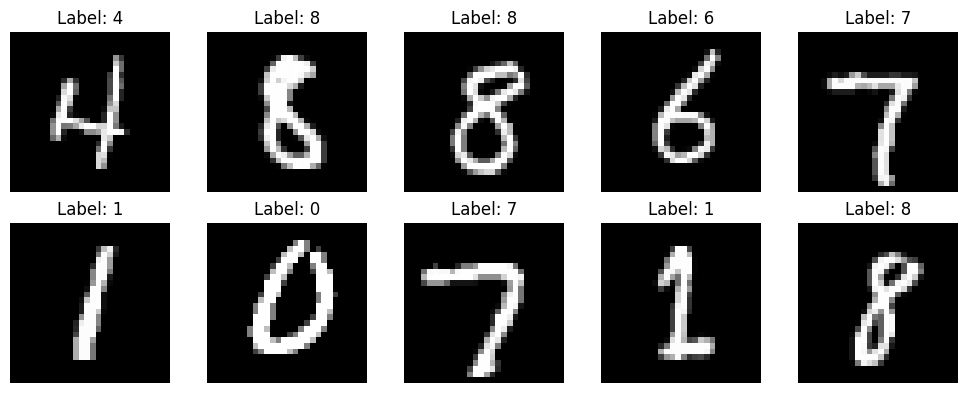

In [24]:
import matplotlib.pyplot as plt

# Plot a few training images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(0), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()


*Batch size, step (iteration), and epoch*

MNIST has **60,000 training images**

- **Batch size = 128**  
  We process 128 images at a time, compute the loss, backprop, and update weights **once**.

- **One step / iteration**  
  = one batch processed  
  = one optimizer update

- **Steps per epoch**  
  $
  \left\lceil \frac{60000}{128} \right\rceil = 469
  $
  (The code above prints `len(train_loader)` which is this value)

- **One epoch**  
  = the model has processed the entire training dataset once  
  = about 469 weight updates

- **10 epochs**  
  = about 4690 total weight updates


---
*Step 2: Define the MLP*

Architecture:
1. Input: 28×28 = **784** features (flattened image)
1. Hidden layer 1: 128 units (ReLU)
1. Hidden layer 2: 64 units (ReLU)
1. Hidden layer 3: 32 units (ReLU)
1. Output: 10 logits (one per digit)

**Important:** We output *logits* (raw scores).
We do **not** apply softmax in the model because `CrossEntropyLoss` expects logits.


In [25]:
# MLP model

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 10)  # logits for 10 classes

    def forward(self, x):
        # x shape: (batch, 1, 28, 28)
        x = x.view(x.size(0), -1)  # flatten to (batch, 784)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        logits = self.fc4(x)       # (batch, 10)
        return logits

model = MLP().to(device)
print(model)


MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=10, bias=True)
)


If any of these shapes don’t match, you likely forgot to flatten or mismatched `in_features` / `out_features`

<br>

*Common shape mistakes (quick checklist)*

If you get a shape error like “mat1 and mat2 shapes cannot be multiplied”, check:

1. **Did you flatten the images?**  
   MNIST images are `(B, 1, 28, 28)` but `nn.Linear` expects `(B, features)`.  
   Use: `x = x.view(x.size(0), -1)` to get `(B, 784)`

2. **Do your `nn.Linear` sizes match?**  
   `nn.Linear(in_features, out_features)` must match the previous layer’s output

   Example: if `fc1` outputs 128, then `fc2` must have `in_features=128`.

3. **Are you mixing up batch dimension?**  
   The first dimension should be batch size `B`. Avoid flattening the whole tensor into one vector (e.g., `x.view(-1)` is wrong here)

4. **Are tensors on the same device?**  
   If model is on GPU, inputs must be moved too: `images = images.to(device)`

5. **Are labels the correct type?**  
   `CrossEntropyLoss` expects class indices of type `torch.long` (usually MNIST already provides this)


In [26]:
# Intentional error demo: forgetting to flatten
images, labels = next(iter(train_loader))
images = images.to(device)

try:
    # This will fail because images are (B, 1, 28, 28) but Linear expects (B, 784)
    out = model.fc1(images)
except RuntimeError as e:
    print("Expected shape error (forgetting to flatten):")
    print(e)


Expected shape error (forgetting to flatten):
mat1 and mat2 shapes cannot be multiplied (3584x28 and 784x128)


In [27]:
# Fix demo: flatten first
x = images.view(images.size(0), -1)  # (B, 784)
out = model.fc1(x)
print("After flattening, fc1 output shape:", out.shape)  # should be (B, 128)


After flattening, fc1 output shape: torch.Size([128, 128])


Now that we’ve seen the most common error, let’s verify the shapes through the full network.


In [28]:
# Shape sanity check (run once before training)
model.eval()
images, labels = next(iter(train_loader))
images = images.to(device)

print("Input batch:", images.shape)  # (B, 1, 28, 28)

with torch.no_grad():
    x = images.view(images.size(0), -1)
    print("Flattened:", x.shape)  # (B, 784)

    x = model.fc1(x); print("After fc1:", x.shape)  # (B, 128)
    x = F.relu(x)

    x = model.fc2(x); print("After fc2:", x.shape)  # (B, 64)
    x = F.relu(x)

    x = model.fc3(x); print("After fc3:", x.shape)  # (B, 32)
    x = F.relu(x)

    logits = model.fc4(x); print("Logits:", logits.shape)  # (B, 10)


Input batch: torch.Size([128, 1, 28, 28])
Flattened: torch.Size([128, 784])
After fc1: torch.Size([128, 128])
After fc2: torch.Size([128, 64])
After fc3: torch.Size([128, 32])
Logits: torch.Size([128, 10])


---
*Step 3: Loss function and optimizer*

We use:
- `CrossEntropyLoss` for multi-class classification (0–9)
- `SGD` + momentum for parameter updates

Common pitfall

> Do **not** apply softmax/log-softmax before `CrossEntropyLoss`
> - Correct: model returns logits -> `CrossEntropyLoss(logits, labels)`
> - If you use `log_softmax`, then use `NLLLoss` instead


In [29]:
# loss + optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

---
*Step 4: Train the model*

Each training step:
1. Forward pass: `logits = model(images)`
1. Loss: `loss = CrossEntropyLoss(logits, labels)`
1. Backprop: `loss.backward()`
1. Update parameters: `optimizer.step()`

**Important:** Gradients accumulate by default in PyTorch. That’s why we call `optimizer.zero_grad()` every step.


In [30]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # enables training behavior (e.g., dropout, batchnorm if present)
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)  # sum of losses over samples

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


---
*Step 5: Evaluate on the test set*

During evaluation:
- Use `model.eval()` to switch to inference behavior
- Use `torch.no_grad()` to avoid tracking gradients (faster, less memory)


In [31]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


---
*Step 6: Run training*

We will print training loss/accuracy and test loss/accuracy after each epoch.


In [32]:
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

Epoch 01/10 | Train Loss: 0.5898, Train Acc: 81.95% | Test Loss: 0.2073, Test Acc: 93.86%
Epoch 02/10 | Train Loss: 0.1690, Train Acc: 94.95% | Test Loss: 0.1233, Test Acc: 96.27%
Epoch 03/10 | Train Loss: 0.1126, Train Acc: 96.66% | Test Loss: 0.1092, Test Acc: 96.58%
Epoch 04/10 | Train Loss: 0.0841, Train Acc: 97.45% | Test Loss: 0.0909, Test Acc: 97.24%
Epoch 05/10 | Train Loss: 0.0660, Train Acc: 97.98% | Test Loss: 0.0937, Test Acc: 97.24%
Epoch 06/10 | Train Loss: 0.0531, Train Acc: 98.34% | Test Loss: 0.0880, Test Acc: 97.48%
Epoch 07/10 | Train Loss: 0.0454, Train Acc: 98.56% | Test Loss: 0.0809, Test Acc: 97.61%
Epoch 08/10 | Train Loss: 0.0353, Train Acc: 98.91% | Test Loss: 0.0765, Test Acc: 97.74%
Epoch 09/10 | Train Loss: 0.0289, Train Acc: 99.11% | Test Loss: 0.0903, Test Acc: 97.53%
Epoch 10/10 | Train Loss: 0.0230, Train Acc: 99.31% | Test Loss: 0.0887, Test Acc: 97.64%


Plot the loss and accuracy curve to check the learning process

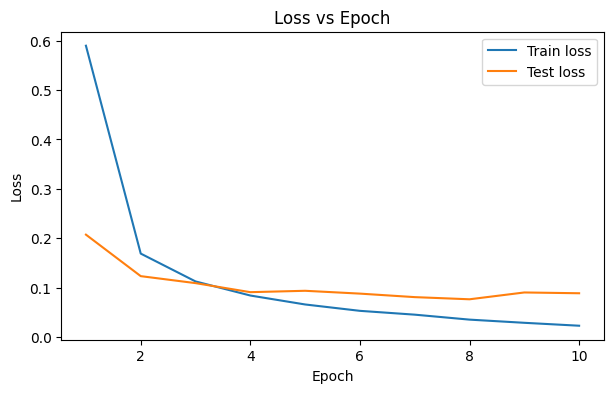

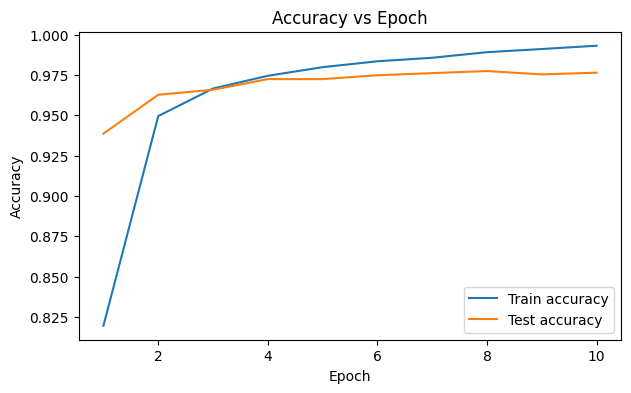

In [33]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

# Loss curve
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, train_losses, label="Train loss")
plt.plot(epochs_range, test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Epoch")
plt.show()

# Accuracy curve
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, train_accs, label="Train accuracy")
plt.plot(epochs_range, test_accs, label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()

Things to check:
- If train loss decreases but test loss increases, you may be ***overfitting***
- If both losses stay high, training might be failing (learning rate, model capacity, preprocessing)

*Visual check: model predictions on test images*

Let's see a few test images and the model's predicted label.

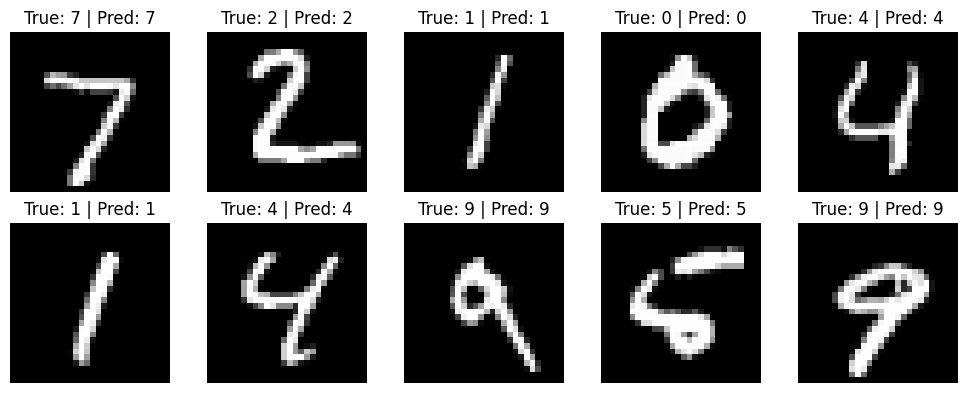

In [34]:
# Plot predictions on test images
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1)

images_cpu = images.cpu()
labels_cpu = labels.cpu()
preds_cpu = preds.cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(images_cpu[i].squeeze(0), cmap="gray")
    ax.set_title(f"True: {labels_cpu[i].item()} | Pred: {preds_cpu[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()


*Common questions / pitfalls to watch out for*

1. **Why does `y.backward()` error when `y` is not a scalar?**  
   `backward()` needs a scalar output or an explicit upstream gradient vector. Loss functions reduce outputs to a scalar.

2. **Why no softmax in the model?**  
   `CrossEntropyLoss` expects logits and applies a stable log-softmax internally.

3. **Why do we call `optimizer.zero_grad()` every step?**  
   Gradients accumulate by default. If you forget this, gradients add up across steps and training becomes incorrect.

4. **Why do we use `model.train()` and `model.eval()`?**  
   Some layers behave differently in training vs inference (dropout, batch norm). Always set the correct mode.

5. **Why might accuracy be lower than expected?**  
   Common causes: wrong normalization, wrong loss/activation pairing, forgetting `.to(device)`, too high/low learning rate, not enough epochs.


## 4. Exercise: Regression with an MLP (California Housing)
<a id="sec4"></a>

[⬆️ Back to Table of Contents](#toc)

*Goal*: Build and train an MLP to **predict a continuous value** (median house price) from tabular features.

*Intuition: classification vs regression*
- **Classification** predicts *which class* -> typically uses **CrossEntropyLoss** and accuracy
- **Regression** predicts a *real number* -> typically uses **MSELoss** (or MAE) and metrics like RMSE / MAE / $R^2$

The training loop is very similar: forward pass -> loss -> backward -> optimizer step.

The key changes are:
1. the **output layer** (usually 1 neuron, no softmax)
1. the **loss function** (e.g., MSE)
1. the **evaluation metrics** (RMSE/MAE/$R^2$)


*What you need to implement*

You will fill in:
1. The `MLPRegression` model (layers + forward pass)
1. The loss function and optimizer
1. The training loop (mini-batch)
1. Evaluation with MSE + at least one extra metric (MAE or $R^2$)

> **Important:** This dataset is tabular (8 features), not images.  
> Input is shape `(batch_size, 8)` and output is shape `(batch_size, 1)`.

*Common pitfalls to watch out for*
- **Data leakage:** fit your scaler on the training set only
- **Output activation:** do **not** use softmax/sigmoid for regression
- **Tensor shapes:** targets should be `(N, 1)` if your model outputs `(N, 1)`
- **Gradients accumulate:** call `optimizer.zero_grad()` each step


In [35]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target  # X: (N, 8), y: (N,)

df = pd.DataFrame(X, columns=data.feature_names)
df["Target"] = y
display(df.head())

print("X shape:", X.shape, "| y shape:", y.shape)
print("Target meaning: median house value in $100,000s (sklearn California housing).")

# Train/test split first (avoid leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit scaler on training data only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# DataLoaders (mini-batch training)
batch_size = 128
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=512,
    shuffle=False
)

print("Steps per epoch:", len(train_loader))


Using device: cuda


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


X shape: (20640, 8) | y shape: (20640,)
Target meaning: median house value in $100,000s (sklearn California housing).
Steps per epoch: 129


*Task 1: Implement the MLPRegression model*

Requirements:
- Input features = **8**
- Use **ReLU** in hidden layers
- Output dimension = **1**
- **No activation** in output layer (we want an unrestricted real-valued prediction)

Fill in the class below.


In [36]:
# TODO: Implement your MLP regression model
class MLPRegression(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: define layers, e.g. 8 -> 128 -> 64 -> 1
        # self.fc1 = ...
        # self.fc2 = ...
        # self.out = ...
        pass

    def forward(self, x):
        # TODO: feedforward
        # x = F.relu(self.fc1(x))
        # x = F.relu(self.fc2(x))
        # y_hat = self.out(x)  # no activation here
        # return y_hat
        pass

model = MLPRegression().to(device)
print(model)


MLPRegression()


*Task 2: Choose loss and optimizer*

For regression, a common loss is **Mean Squared Error** (MSE):

$
\mathrm{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2
$

Use:
- `nn.MSELoss()` as the loss
- `optim.Adam(...)` as the optimizer (start with a learning rate like `1e-3`)

In [37]:
# TODO: define loss function and optimizer
# criterion = ...
# optimizer = ...

# Suggested defaults (you can tune):
# criterion = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-3)

*Task 3: Train the model (mini-batch)*

Implement training for a chosen number of epochs.

Tip: start with `epochs=50` and see how the loss changes.

What you should do each batch:
1. move tensors to `device`
1. forward pass
1. compute loss
1. backward pass
1. optimizer step

In [38]:
# TODO: training loop
epochs = 50

train_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # TODO: zero gradients
        # TODO: forward
        # TODO: loss
        # TODO: backward
        # TODO: step

        # running_loss += loss.item() * xb.size(0)
        # n_samples += xb.size(0)

        pass

    # avg_loss = running_loss / n_samples
    # train_losses.append(avg_loss)
    # if epoch % 10 == 0:
    #     print(f"Epoch {epoch:03d}/{epochs} | Train MSE: {avg_loss:.4f}")

print("Finished training (once you implement the TODOs).")


Finished training (once you implement the TODOs).


*Task 4: Evaluate on the test set*

Compute:
- Test MSE
- RMSE (square root of MSE)
- MAE (mean absolute error)
- $R^2$ score (optional but recommended)

Also, make a scatter plot of **predicted vs true** values:
- If the model is perfect, points lie on the diagonal line

In [39]:
# TODO: evaluation
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        # TODO: preds = model(xb)
        # all_preds.append(preds)
        # all_targets.append(yb)
        pass

# TODO: concatenate, move to CPU numpy
# preds = torch.cat(all_preds, dim=0).detach().cpu().numpy()
# targets = torch.cat(all_targets, dim=0).detach().cpu().numpy()

# TODO: compute metrics (MSE, RMSE, MAE, R^2) and print them
# TODO: scatter plot (targets vs preds)

*Baseline: “predict the mean” (sanity check)*

Before trusting our neural network, it’s good practice to compare against a simple baseline.

A common baseline for regression is: **always predict the mean target value from the training set**.

If your MLP cannot beat this baseline, something is likely wrong (model too small, learning rate off, training bug, etc.).


In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Baseline predictor: always predict mean of training targets
train_mean = y_train.mean()
baseline_preds = np.full_like(y_test, fill_value=train_mean, dtype=np.float64)

baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_r2 = r2_score(y_test, baseline_preds)

print("Baseline (predict training mean):")
print(f"  MSE : {baseline_mse:.4f}")
print(f"  RMSE: {baseline_rmse:.4f}")
print(f"  MAE : {baseline_mae:.4f}")
print(f"  R^2 : {baseline_r2:.4f}")


Baseline (predict training mean):
  MSE : 1.3107
  RMSE: 1.1449
  MAE : 0.9061
  R^2 : -0.0002


*What does $R^2$ mean?*

The $R^2$ score measures how much better your model is compared to the baseline that predicts the mean.

$
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$

- $R^2 = 1$: perfect predictions  
- $R^2 = 0$: no better than predicting the mean  
- $R^2 < 0$: worse than predicting the mean


### Solution (one possible implementation)

***Please attend solving the exercise on your own before checking the solution below.***

Compare your implementation with the reference below.  
There are many valid choices of layer sizes, learning rate, and epochs.

Epoch 001/50 | Train MSE: 1.6540
Epoch 010/50 | Train MSE: 0.3280
Epoch 020/50 | Train MSE: 0.2840
Epoch 030/50 | Train MSE: 0.2717
Epoch 040/50 | Train MSE: 0.2563
Epoch 050/50 | Train MSE: 0.2486


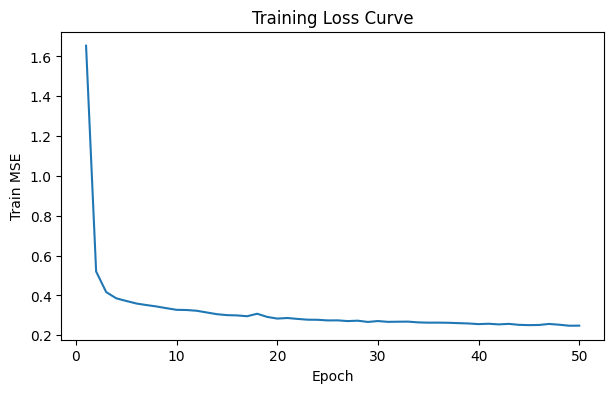

Test MSE : 0.2756
Test RMSE: 0.5250
Test MAE : 0.3595
Test R^2 : 0.7897


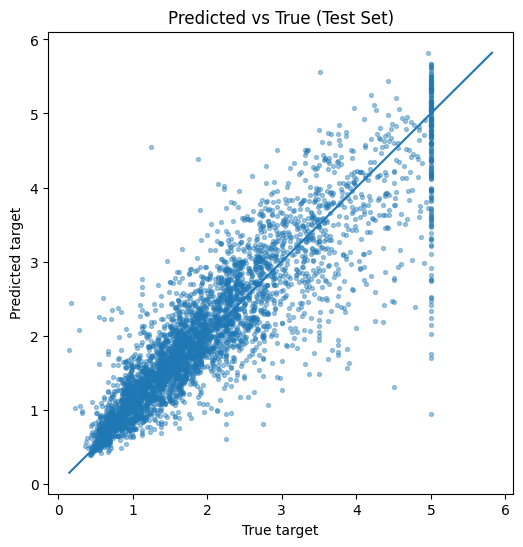

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

class MLPRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.out(x)  # no activation for regression

model = MLPRegression().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
train_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)

    avg_loss = running_loss / n_samples
    train_losses.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{epochs} | Train MSE: {avg_loss:.4f}")

# Plot training curve
plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training Loss Curve")
plt.show()

# Evaluation
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        all_preds.append(preds)
        all_targets.append(yb)

preds = torch.cat(all_preds, dim=0).detach().cpu().numpy()
targets = torch.cat(all_targets, dim=0).detach().cpu().numpy()

mse = mean_squared_error(targets, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets, preds)
r2 = r2_score(targets, preds)

print(f"Test MSE : {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE : {mae:.4f}")
print(f"Test R^2 : {r2:.4f}")

# Predicted vs True scatter
plt.figure(figsize=(6,6))
plt.scatter(targets, preds, s=8, alpha=0.4)
min_v = min(targets.min(), preds.min())
max_v = max(targets.max(), preds.max())
plt.plot([min_v, max_v], [min_v, max_v])  # diagonal reference line
plt.xlabel("True target")
plt.ylabel("Predicted target")
plt.title("Predicted vs True (Test Set)")
plt.show()

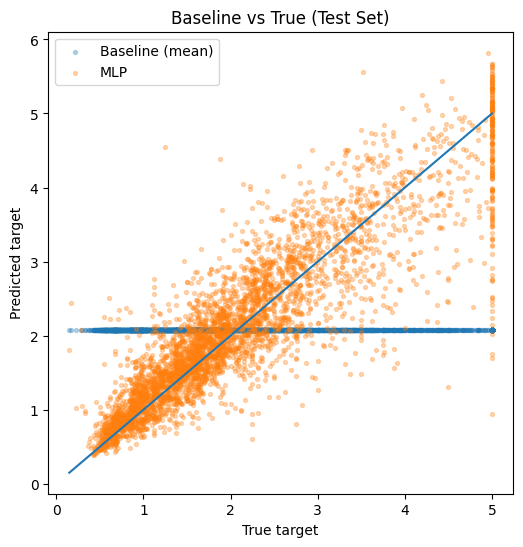

In [42]:
# compare baseline vs model on a scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, baseline_preds, s=8, alpha=0.3, label="Baseline (mean)")
plt.scatter(y_test, preds.squeeze(), s=8, alpha=0.3, label="MLP")

min_v = min(y_test.min(), baseline_preds.min())
max_v = max(y_test.max(), baseline_preds.max())
plt.plot([min_v, max_v], [min_v, max_v])  # diagonal reference
plt.xlabel("True target")
plt.ylabel("Predicted target")
plt.title("Baseline vs True (Test Set)")
plt.legend()
plt.show()

### Optional challenges
1. Try changing hidden sizes (e.g., 64->32->16) and compare RMSE
1. Try a different learning rate (1e-4, 1e-3, 1e-2). What happens?
1. Add L2 regularization: `optim.Adam(..., weight_decay=1e-4)`
1. Compute baseline performance by predicting the training mean for all test samples


## 5. Optional Advanced: Convolutional Neural Networks (CNNs)
<a id="sec5"></a>

[⬆️ Back to Table of Contents](#toc)

This section is **optional/advanced**. You can skip it if you're focusing on the MLP basics.




*Why CNNs for images?*

- An MLP flattens an image into a long vector, which loses explicit spatial structure (pixels next to each other).

- A CNN uses **convolutions** to learn local patterns (edges, strokes) and becomes the standard baseline for image tasks.

- **Goal:** Train a simple CNN on MNIST and compare performance to the MLP.

*CNN strategy (high level)*

We will use:
- Two convolution blocks: `Conv2d -> ReLU -> MaxPool2d`
- Then flatten and use fully connected layers to output **10 logits**
- Loss: `CrossEntropyLoss` (same as before)
- Optimizer: Adam


In [43]:
# Data loaders + steps/epoch calculation
# Same as before when use MLP
# Note, for future, if you don't want to reload it, you can name different dataset explicitly, e.g., mnist_train_loader, mnist_test_loader

batch_size = 128
test_batch_size = 256
epochs = 10
lr = 0.01
momentum = 0.9

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST("../data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST("../data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

steps_per_epoch = len(train_loader)  # equals ceil(N / batch_size)
print("Train set size:", len(train_dataset))
print("Batch size:", batch_size)
print("Steps per epoch:", steps_per_epoch)
print("Total training steps:", steps_per_epoch * epochs)

Train set size: 60000
Batch size: 128
Steps per epoch: 469
Total training steps: 4690


In [44]:
class CNNNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: (B, 1, 28, 28)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)  # -> (B, 32, 28, 28)
        self.conv2 = nn.Conv2d(32, 64, 5, 1, 2)  # -> (B, 64, 14, 14) after first pool, then -> (B, 64, 14, 14)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves H,W

        # After conv1+pool: (B, 32, 14, 14)
        # After conv2+pool: (B, 64, 7, 7)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(128, 10)  # logits

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)  # (B, 64*7*7)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        return logits


*Quick shape sanity check (optional)*

Run this once to confirm that the CNN sees `(B,1,28,28)` and produces `(B,10)` logits.


In [45]:
cnn = CNNNet().to(device)
cnn.eval()

images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    logits = cnn(images)
print("Input shape :", images.shape)
print("Logits shape:", logits.shape)  # should be (batch_size, 10)


Input shape : torch.Size([128, 1, 28, 28])
Logits shape: torch.Size([128, 10])


Following shows how convolutions keep the spatial grid (H×W) while pooling reduces it (28->14->7) and channels increase (1->32->64).


In [46]:
# feature map shape walkthrough
cnn = CNNNet().to(device)
cnn.eval()

images, _ = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    x = images
    print("Start:", x.shape)  # (B, 1, 28, 28)

    x = cnn.conv1(x)
    print("After conv1:", x.shape)  # (B, 32, 28, 28)
    x = F.relu(x)

    x = cnn.pool(x)
    print("After pool1:", x.shape)  # (B, 32, 14, 14)

    x = cnn.conv2(x)
    print("After conv2:", x.shape)  # (B, 64, 14, 14)
    x = F.relu(x)

    x = cnn.pool(x)
    print("After pool2:", x.shape)  # (B, 64, 7, 7)

    x = x.view(x.size(0), -1)
    print("After flatten:", x.shape)  # (B, 64*7*7)

    x = cnn.fc1(x)
    print("After fc1:", x.shape)  # (B, 128)

    x = cnn.fc2(F.relu(x))
    print("After fc2 (logits):", x.shape)  # (B, 10)


Start: torch.Size([128, 1, 28, 28])
After conv1: torch.Size([128, 32, 28, 28])
After pool1: torch.Size([128, 32, 14, 14])
After conv2: torch.Size([128, 64, 14, 14])
After pool2: torch.Size([128, 64, 7, 7])
After flatten: torch.Size([128, 3136])
After fc1: torch.Size([128, 128])
After fc2 (logits): torch.Size([128, 10])


*Train and evaluate the CNN*

This reuses the same training/evaluation pattern as the MLP section.


In [47]:
def train_one_epoch_classification(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate_classification(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


In [48]:
# Train CNN for 10 epochs

cnn = CNNNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=1e-3)

epochs = 10
cnn_train_losses, cnn_test_losses = [], []
cnn_train_accs, cnn_test_accs = [], []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch_classification(cnn, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate_classification(cnn, test_loader, criterion, device)

    cnn_train_losses.append(train_loss)
    cnn_test_losses.append(test_loss)
    cnn_train_accs.append(train_acc)
    cnn_test_accs.append(test_acc)

    print(f"[CNN] Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")


[CNN] Epoch 01/10 | Train Loss: 0.1768, Train Acc: 94.42% | Test Loss: 0.0492, Test Acc: 98.46%
[CNN] Epoch 02/10 | Train Loss: 0.0596, Train Acc: 98.16% | Test Loss: 0.0321, Test Acc: 98.92%
[CNN] Epoch 03/10 | Train Loss: 0.0482, Train Acc: 98.49% | Test Loss: 0.0266, Test Acc: 99.02%
[CNN] Epoch 04/10 | Train Loss: 0.0382, Train Acc: 98.75% | Test Loss: 0.0272, Test Acc: 99.09%
[CNN] Epoch 05/10 | Train Loss: 0.0313, Train Acc: 98.96% | Test Loss: 0.0225, Test Acc: 99.21%
[CNN] Epoch 06/10 | Train Loss: 0.0277, Train Acc: 99.12% | Test Loss: 0.0255, Test Acc: 99.14%
[CNN] Epoch 07/10 | Train Loss: 0.0256, Train Acc: 99.17% | Test Loss: 0.0228, Test Acc: 99.26%
[CNN] Epoch 08/10 | Train Loss: 0.0230, Train Acc: 99.24% | Test Loss: 0.0231, Test Acc: 99.21%
[CNN] Epoch 09/10 | Train Loss: 0.0204, Train Acc: 99.30% | Test Loss: 0.0222, Test Acc: 99.27%
[CNN] Epoch 10/10 | Train Loss: 0.0189, Train Acc: 99.39% | Test Loss: 0.0205, Test Acc: 99.44%


*Plot CNN learning curves*

This helps us see whether the model is still improving or starting to overfit.


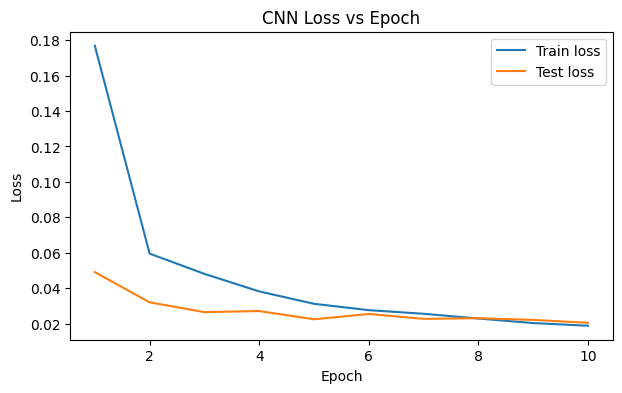

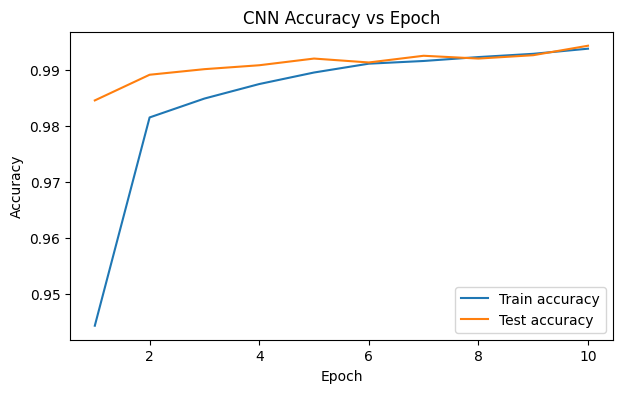

In [49]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, cnn_train_losses, label="Train loss")
plt.plot(epochs_range, cnn_test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss vs Epoch")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, cnn_train_accs, label="Train accuracy")
plt.plot(epochs_range, cnn_test_accs, label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy vs Epoch")
plt.legend()
plt.show()


*Common pitfalls (CNN)*
- **Wrong input shape:** CNN expects `(batch, channels, height, width)` = `(B, 1, 28, 28)` for MNIST.
- **Forgetting `model.eval()` during testing:** dropout stays on and results are noisy.
- **Device mismatch:** if model is on GPU, inputs must be on GPU too.
- **Softmax + CrossEntropyLoss:** don't apply softmax in the model; return logits.

\
*Further learning pointers (if you're curious)*
- Try adding **BatchNorm** after convolutions
- Try a deeper architecture (3 conv blocks)
- Read about classic CNNs: LeNet-5, AlexNet (historical), and modern ResNets
- Look up: "data augmentation" (random shifts/rotations) to improve robustness
